In [1]:
import numpy as np
import matplotlib.pyplot as plt
import src.routines.tomo_fusion.tools.plotting_fcts as tomo_plots
import copy
import skimage.transform as skimt
import skimage.filters as skimf

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
Nz, Nr = 120, 41
tcv_zmin, tcv_zmax = -0.75, 0.75
tcv_rmin, tcv_rmax = 0.624, 1.1376
dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2

In [4]:
geometry_matrix = np.load("../../tcv_geometry/geometry_matrix_NINO.npy")
tcv_mask = np.load("../../tcv_geometry/tcv_mask_1_subpixels_NINO.npy")

# Generate SOLPS-like phantoms

In [6]:
def define_composite_phantom(coeffs, psi, trim_params=None, dim_shape=(120,41)):
    # coeffs: np.array([coeff_in, coeff_out, coeff_ring_core_solps, coeff_xpt_rad, coeff_core])
    xpoint_z_idx_base_psi=90 #, 14]
    xpoint_r_idx_base_psi=14
    if trim_params is None:
        trim_params = np.zeros(4)
    upper_trim = int(trim_params[0])# * np.random.rand())
    lower_trim = int(120 - trim_params[1])# * np.random.rand())
    hfs_trim = int(trim_params[2])# * np.random.rand())
    lfs_trim = int(40 - trim_params[3])# * np.random.rand())
    trimming_vals = np.array([upper_trim, lower_trim, hfs_trim, lfs_trim])
    z_xpoint_idx = int(dim_shape[0] * (xpoint_z_idx_base_psi - trimming_vals[0]) / (
                     trimming_vals[1] - trimming_vals[0]))
    # r_xpoint_idx = int(dim_shape[1] * (xpoint_r_idx_base_psi - trimming_vals[2]) / (
    #                  trimming_vals[3] - trimming_vals[2]))
    psi_resh = skimt.resize(psi[upper_trim:lower_trim, hfs_trim:lfs_trim], dim_shape, anti_aliasing=True, mode='edge')
    idxs_neg_psi = np.where(psi_resh<0)
    idxs_core = (idxs_neg_psi[0][idxs_neg_psi[0]<z_xpoint_idx],
             idxs_neg_psi[1][idxs_neg_psi[0]<z_xpoint_idx])
    mask_core = np.zeros(dim_shape, dtype=bool)
    mask_core[idxs_core] = True

    inner_leg = skimt.resize(solps_ph_inner_leg[upper_trim:lower_trim, hfs_trim:lfs_trim], dim_shape, anti_aliasing=True, mode='edge')
    inner_leg /= np.max(inner_leg)
    outer_leg = skimt.resize(solps_ph_outer_leg[upper_trim:lower_trim, hfs_trim:lfs_trim], dim_shape, anti_aliasing=True, mode='edge')
    outer_leg /= np.max(outer_leg)
    ring_and_core = skimt.resize(solps_ph_ring_and_core[upper_trim:lower_trim, hfs_trim:lfs_trim], dim_shape, anti_aliasing=True, mode='edge')
    ring_and_core /= np.max(ring_and_core)

    xpoint_rad = skimt.resize(xpt_rad[upper_trim:lower_trim, hfs_trim:lfs_trim], dim_shape, anti_aliasing=True, mode='edge')

    core = np.exp(-((psi_resh-np.min(psi_resh))/(np.min(psi_resh)))**2 / (2*0.5**2))
    core *= mask_core
    core = skimf.gaussian(core, sigma=1.5)

    phantom = coeffs[0]*inner_leg + coeffs[1]*outer_leg + coeffs[2]*ring_and_core +\
              coeffs[3]*xpoint_rad + coeffs[4]*core
    #trimming_values[i, :] = np.array([upper_trim, lower_trim, hfs_trim, lfs_trim])
    #phantom = skimf.gaussian(phantom, sigma=0.5)
    return phantom, psi_resh, trimming_vals

## Figure 5
Building blocks used to generate each phantom

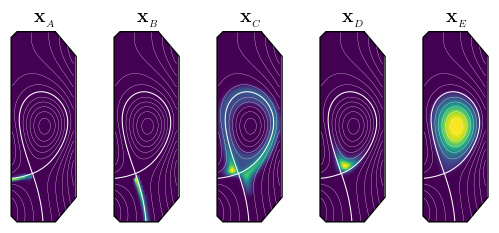

In [15]:
solps_ph_inner_leg = np.load("phantoms/solps_phantom_inner_leg.npy")
solps_ph_outer_leg = np.load('phantoms/solps_phantom_outer_leg.npy')
solps_ph_ring_and_core = np.load('phantoms/solps_phantom_ring_and_core.npy')
xpt_rad = np.load('phantoms/xpt_rad.npy')
mag_eq = np.load('phantoms/magnetic_equilibrium.npy')
phantom_building_blocks = [solps_ph_inner_leg, solps_ph_outer_leg, solps_ph_ring_and_core, xpt_rad, core]
#titles = [r"$\mathrm{inner\;leg}$", r"$\mathrm{outer\;leg}$", r"$\mathrm{scrape\!\!-\!\!off layer}$", r"$\mathrm{X-pt radiation}$", r"$\mathrm{core}$"]
titles = [r"$\mathbf{x}_{_A}$", r"$\mathbf{x}_{_B}$", r"$\mathbf{x}_{_C}$", r"$\mathbf{x}_{_D}$", r"$\mathbf{x}_{_E}$"]
mag_eq = np.load('phantoms/magnetic_equilibrium.npy')


fig,ax=plt.subplots(1,5, figsize=(6.2,2.5), width_ratios=[1,1,1,1,1])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})
plt.subplots_adjust(wspace=0.5)
for i, phantom_element in enumerate(phantom_building_blocks):
    tomo_plots.plot_profile(phantom_element, tcv_plot_clip=True, contour_image=mag_eq,
                         ax=ax[i], colorbar=False, contour_color="w", vmax=None, aspect=None, levels=12)
    ax[i].set_title(titles[i], fontsize=14)
    
#plt.savefig('figures/phantom_dataset_building_blocks_nocbar.eps', format='eps', bbox_inches="tight")

plt.show()

## Figure 6

Example of model phantoms from the generated synthetic dataset

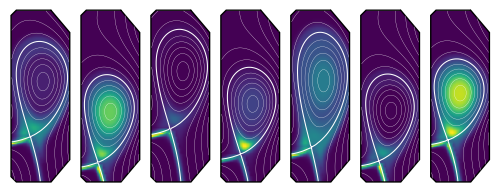

In [20]:
fig,ax=plt.subplots(1,7, figsize=(6.2,2.5), width_ratios=[1,1,1,1,1,1,1])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})
plt.subplots_adjust(wspace=0.15)

phantoms = np.load("phantoms/phantoms.npy")
phantoms_psis = np.load("phantoms/phantoms_psis.npy")

idxs_to_be_plotted = np.array([80,297,102,5,180,265,383])

for i, idx in enumerate(idxs_to_be_plotted):
    tomo_plots.plot_profile(phantoms[idx, :, :], tcv_plot_clip=True, contour_image=phantoms_psis[idx, :, :],
                         ax=ax[i], colorbar=False, contour_color="w", vmax=None, aspect=None, levels=12)
    
#plt.savefig('figures/phantom_dataset_nocbar.eps', format='eps', bbox_inches="tight")

plt.show()

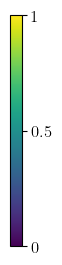

In [19]:
#r=plt.imshow(gaussian_profile)
plt.figure(figsize=(2,3))
r=plt.imshow(phantoms[idx,:,:]/np.max(phantoms[idx,:,:]))
plt.gca().set_visible(False)
cbar=plt.colorbar(r, aspect=20)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_yticks([0,0.5,1])
cbar.ax.set_yticklabels([r"$0$",  r"$0.5$", r"$1$"])
plt.axis("off")
#plt.savefig('figures/phantoms_cbar.eps', format='eps', bbox_inches="tight")
plt.show()

# Results of the hyperparameter study

In [21]:
# aggregate results
ph0 = np.load("phantom_analysis_results/phantom_%d.npy" % 0, allow_pickle=True).item()
prads_tot = np.zeros((1000, 5, 7, 5))
prads_core = np.zeros((1000, 5, 7, 5))
prads_tot_true = np.zeros(1000)
prads_core_true = np.zeros(1000)
time = np.zeros((1000, 5, 7, 5))
for i in range(1000):
    ph = np.load("phantom_analysis_results/phantom_%d.npy" % i, allow_pickle=True).item()
    prads_tot[i, :, :, :] = ph["prads_tot"].reshape(5, 7, 5)
    prads_core[i, :, :, :] = ph["prads_core"].reshape(5, 7, 5)
    prads_tot_true[i] = ph["prad_tot_true"]
    prads_core_true[i] = ph["prad_core_true"]

hyperparameters = ph["hyperparameters"]

In [23]:
relative_errors_tot = np.abs(prads_tot.reshape(1000,-1) - prads_tot_true.reshape(-1,1)) / prads_tot_true.reshape(-1,1)
relative_errors_tot = relative_errors_tot.reshape(1000, 5, 7, 5)
relative_errors_core = np.abs(prads_core.reshape(1000,-1) - prads_core_true.reshape(-1,1)) / prads_core_true.reshape(-1,1)
relative_errors_core = relative_errors_core.reshape(1000, 5, 7, 5)

In [24]:
relative_errors_posneg_tot = (prads_tot.reshape(1000,-1) - prads_tot_true.reshape(-1,1)) / prads_tot_true.reshape(-1,1)
relative_errors_posneg_tot = relative_errors_posneg_tot.reshape(1000, 5, 7, 5)
relative_errors_posneg_core = (prads_core.reshape(1000,-1) - prads_core_true.reshape(-1,1)) / prads_core_true.reshape(-1,1)
relative_errors_posneg_core = relative_errors_posneg_core.reshape(1000, 5, 7, 5)

In [26]:
reg_params = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
anis_params = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
sigma_errs = np.array([1e-2, 2.5e-2, 5e-2, 7.5e-2, 1e-1])

## Relative error (no absolute value)

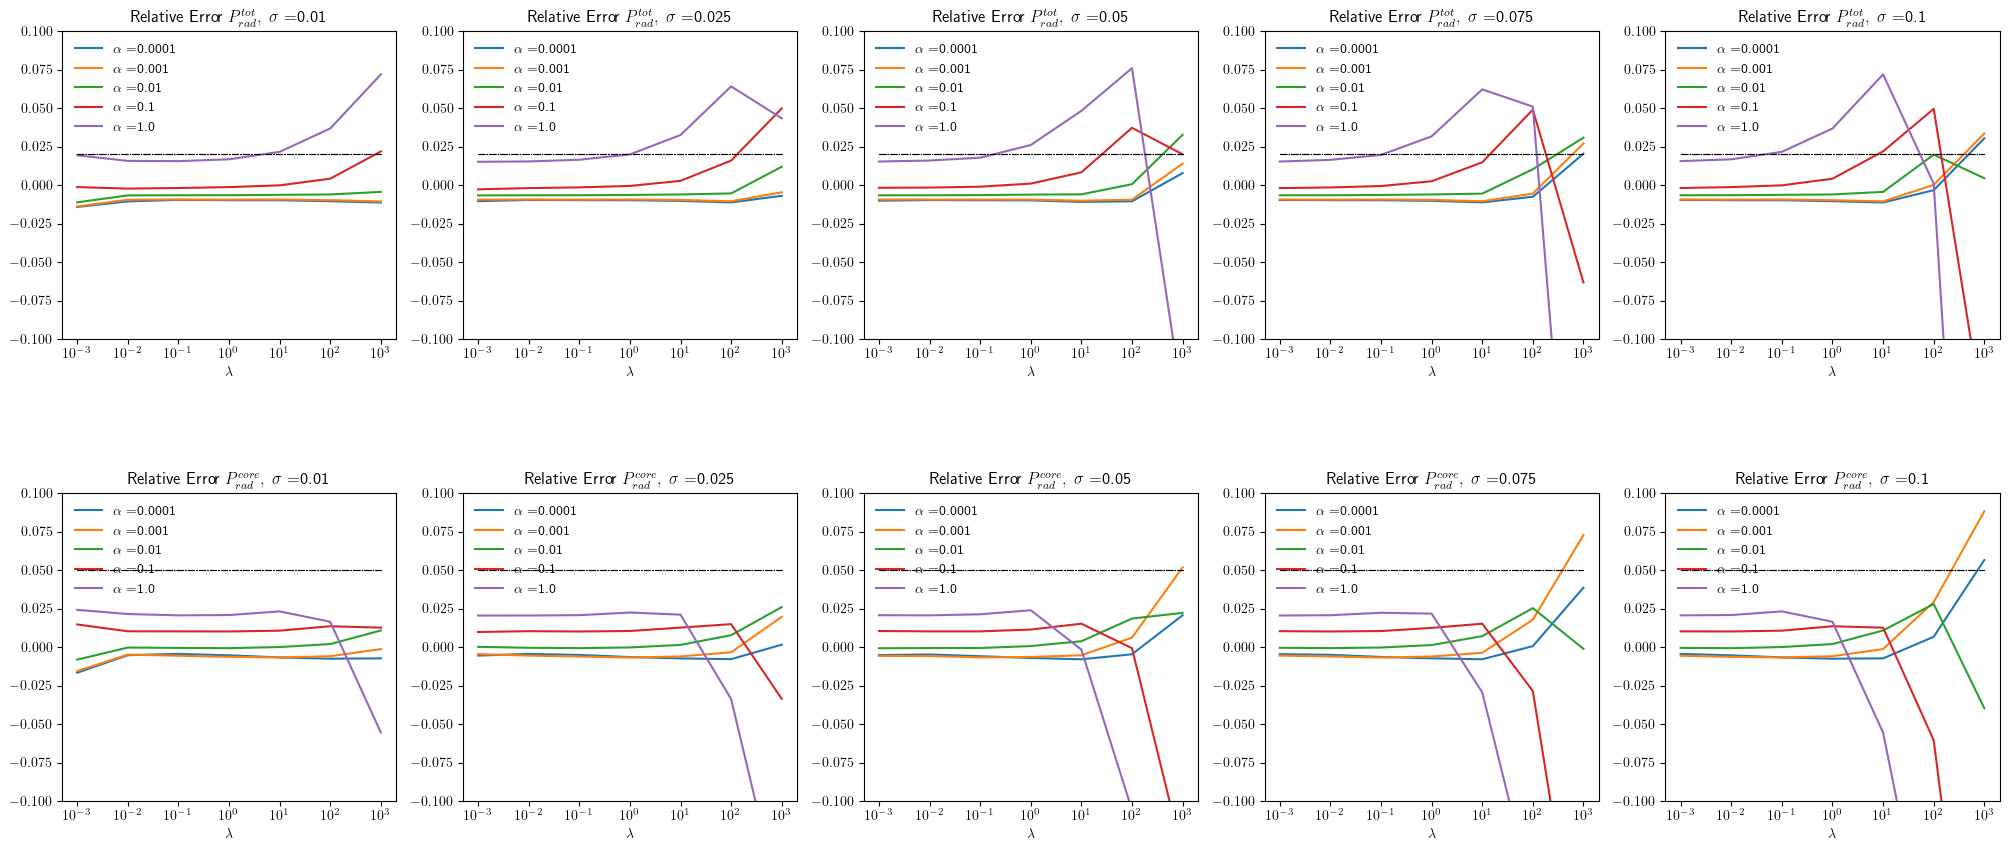

In [32]:
# generate plots for analysis 

fig, ax = plt.subplots(2,5, figsize=(25,10))
plt.subplots_adjust(hspace=0.5)

for i in range(5):
    data_to_be_plotted = relative_errors_posneg_tot[:, i, :, :]
    for j in range(5):
        ax[0, i].plot(np.mean(data_to_be_plotted[:, :, j], axis=0), label=r"$\alpha=$"+str(anis_params[j]))
        ax[0, i].plot(np.ones(7)*0.02, 'k-.', linewidth=0.75)
    ax[0, i].set_title(r"Relative Error $P_{rad}^{tot}, \; \sigma=$"+str(sigma_errs[i]))
    ax[0, i].set_xticks([0,1,2,3,4,5,6])
    ax[0, i].set_xticklabels([r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    ax[0, i].set_xlabel(r"$\lambda$")
    ax[0, i].set_ylim([-0.1,0.1])
    ax[0, i].legend(loc="upper left", frameon=False)
    
for i in range(5):
    data_to_be_plotted = relative_errors_posneg_core[:, i, :, :]
    for j in range(5):
        ax[1, i].plot(np.mean(data_to_be_plotted[:, :, j], axis=0), label=r"$\alpha=$"+str(anis_params[j]))
        ax[1, i].plot(np.ones(7)*0.05, 'k-.', linewidth=0.75)
    ax[1, i].set_title(r"Relative Error $P_{rad}^{core}, \; \sigma=$"+str(sigma_errs[i]))
    ax[1, i].set_xticks([0,1,2,3,4,5,6])
    ax[1, i].set_xticklabels([r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    ax[1, i].set_xlabel(r"$\lambda$")
    ax[1, i].set_ylim([-0.1,0.1])
    ax[1, i].legend(loc="upper left", frameon=False)


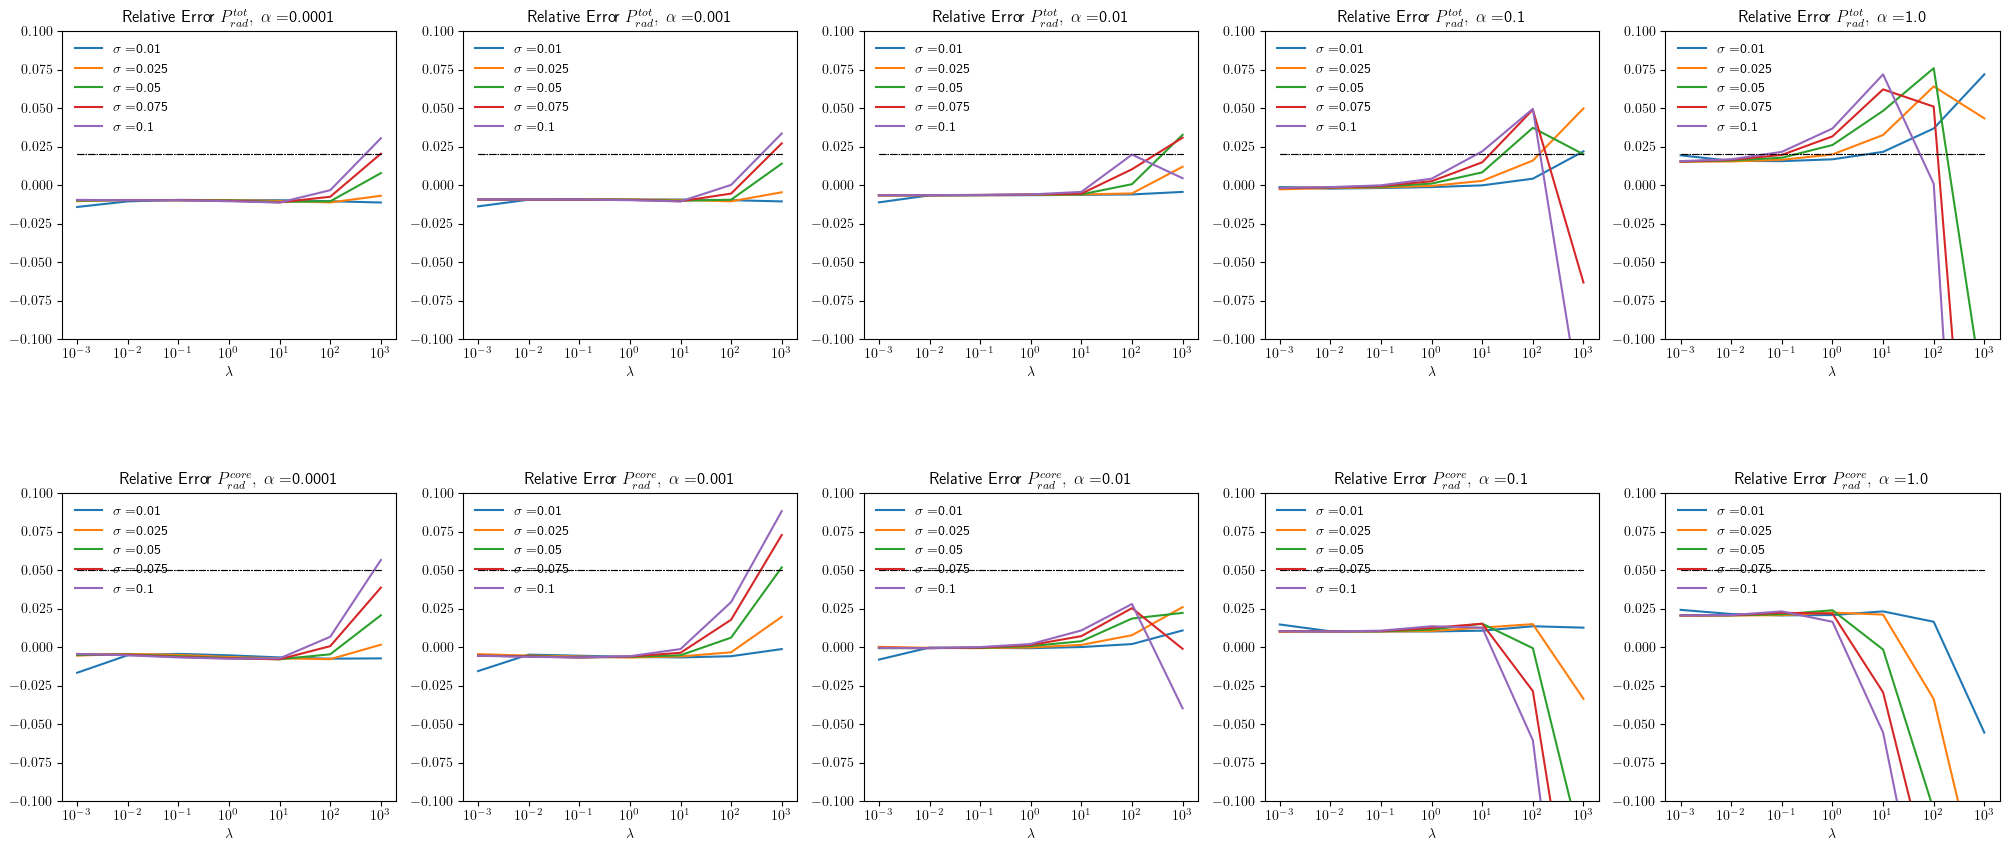

In [33]:
# generate plots for analysis 

fig, ax = plt.subplots(2,5, figsize=(25,10))
plt.subplots_adjust(hspace=0.5)

for i in range(5):
    data_to_be_plotted = relative_errors_posneg_tot[:, :, :, i]
    for j in range(5):
        ax[0, i].plot(np.mean(data_to_be_plotted[:, j, :], axis=0), label=r"$\sigma=$"+str(sigma_errs[j]))
        ax[0, i].plot(np.ones(7)*0.02, 'k-.', linewidth=0.75)
    ax[0, i].set_title(r"Relative Error $P_{rad}^{tot}, \; \alpha=$"+str(anis_params[i]))
    ax[0, i].set_xticks([0,1,2,3,4,5,6])
    ax[0, i].set_xticklabels([r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    ax[0, i].set_xlabel(r"$\lambda$")
    ax[0, i].set_ylim([-0.1,0.1])
    ax[0, i].legend(loc="upper left", frameon=False)
    
for i in range(5):
    data_to_be_plotted = relative_errors_posneg_core[:, :, :, i]
    for j in range(5):
        ax[1, i].plot(np.mean(data_to_be_plotted[:, j, :], axis=0), label=r"$\sigma=$"+str(sigma_errs[j]))
        ax[1, i].plot(np.ones(7)*0.05, 'k-.', linewidth=0.75)
    ax[1, i].set_title(r"Relative Error $P_{rad}^{core}, \;  \alpha=$"+str(anis_params[i]))
    ax[1, i].set_xticks([0,1,2,3,4,5,6])
    ax[1, i].set_xticklabels([r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    ax[1, i].set_xlabel(r"$\lambda$")
    ax[1, i].set_ylim([-0.1,0.1])
    ax[1, i].legend(loc="upper left", frameon=False)


In [34]:
# select alpha=0.01, sigma=0.025, reg_param=1e1 for anisotropic approach; sigma=0.025, reg_param=1e0 for isotropic appproach

anisotropic_model_rel_errs_posneg_tot = relative_errors_posneg_tot[:, 1, 4, 2]
anisotropic_model_rel_errs_posneg_core = relative_errors_posneg_core[:, 1, 4, 2]

isotropic_model_rel_errs_posneg_tot = relative_errors_posneg_tot[:, 1, 3, 4]
isotropic_model_rel_errs_posneg_core = relative_errors_posneg_core[:, 1, 3, 4]

best_rel_errs_posneg_tot = np.min(np.abs(relative_errors_posneg_tot).reshape(1000, -1), axis=1)
best_rel_errs_posneg_core = np.min(np.abs(relative_errors_posneg_core).reshape(1000, -1), axis=1)

print("Performance of selected anisotropic model")
print("  relative error total Prad : ", np.mean(anisotropic_model_rel_errs_posneg_tot), "+-", np.std(anisotropic_model_rel_errs_posneg_tot))
print("  relative error core Prad : ", np.mean(anisotropic_model_rel_errs_posneg_core), "+-", np.std(anisotropic_model_rel_errs_posneg_core))
print("\n")

print("Performance of selected isotropic model")
print("  relative error total Prad : ", np.mean(isotropic_model_rel_errs_posneg_tot), "+-", np.std(isotropic_model_rel_errs_posneg_tot))
print("  relative error core Prad : ", np.mean(isotropic_model_rel_errs_posneg_core), "+-", np.std(isotropic_model_rel_errs_posneg_core))
print("\n")

print("Performance of best model")
print("  relative error total Prad : ", np.mean(best_rel_errs_posneg_tot), "+-", np.std(best_rel_errs_posneg_tot))
print("  relative error core Prad : ", np.mean(best_rel_errs_posneg_core), "+-", np.std(best_rel_errs_posneg_core))

Performance of selected anisotropic model
  relative error total Prad :  -0.006057584140816399 +- 0.027835348880518383
  relative error core Prad :  0.0014455482611341211 +- 0.10693388574948375


Performance of selected isotropic model
  relative error total Prad :  0.01993699140583305 +- 0.033924765887424026
  relative error core Prad :  0.022455822037830607 +- 0.18155645736507686


Performance of best model
  relative error total Prad :  0.001721742861411752 +- 0.006089718960992544
  relative error core Prad :  0.006973587966424065 +- 0.03357950682505164


(0.0, 6.0)

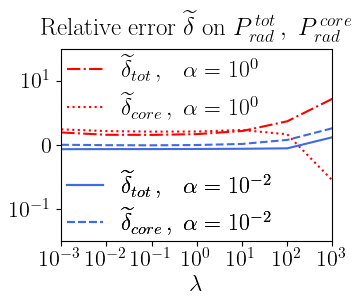

In [35]:
fig,ax=plt.subplots(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})
l1,=ax.plot(np.mean(relative_errors_posneg_tot[:, 0, :, 4], axis=0), 'r-.', label=r"$\delta_{{tot}}^{P_{rad}}, \alpha=10^{0}$")
l2,=ax.plot(np.mean(relative_errors_posneg_core[:, 0, :, 4], axis=0), 'r:', label=r"$\delta_{{core}}^{P_{rad}^{\,core}}, \alpha=10^0$")
legend1=ax.legend(handles=[l1,l2],
                   labels=[r"$\widetilde{\delta}_{tot}\,,\; \;\,\alpha=10^0$", r"$\widetilde{\delta}_{core}\,, \;\alpha=10^0$"],
                   loc="upper left", frameon=False, ncols=1, handlelength=1.5, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.25)
ax.add_artist(legend1)
l3,=ax.plot(np.mean(relative_errors_posneg_tot[:, 1, :, 2], axis=0), color="royalblue", label=r"$\delta_{{tot}}^{P_{rad}}, \alpha=10^{-2}$")
l4,=ax.plot(np.mean(relative_errors_posneg_core[:, 1, :, 2], axis=0), '--', color="royalblue", label=r"$\delta_{{core}}^{P_{rad}}, \alpha=10^{-2}$")
legend2=ax.legend(handles=[l3,l4],
                  labels=[r"$\widetilde{\delta}_{tot}\,,\; \;\,\alpha=10^{-2}$", r"$\widetilde{\delta}_{core}\,, \;\alpha=10^{-2}$"],
                  loc="lower left", frameon=False, ncols=1, handlelength=1.5, fontsize=17, labelspacing=0.4, borderpad=0, borderaxespad=0.25)
ax.add_artist(legend2)
plt.title(r"$\mathrm{Relative\;error}\;\widetilde{\delta}\;\mathrm{on}\;P_{rad}^{\,tot}\,,\;P_{rad}^{\,core}$", fontsize=18, y=1.03)
plt.xticks([0,1,2,3,4,5,6], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"], fontsize=16) 
plt.yticks([-0.1,0,0.1], [r"$10^{-1}$", r"$0$", r"$10^{1}$"], fontsize=16) 
plt.xlabel(r"$\lambda$", fontsize=17)
plt.ylim([-0.15,0.15])
plt.xlim([0,6])
#plt.savefig('figures/hyperparameter_tuning.eps', format='eps', bbox_inches="tight")

(-1.0, 1.0)

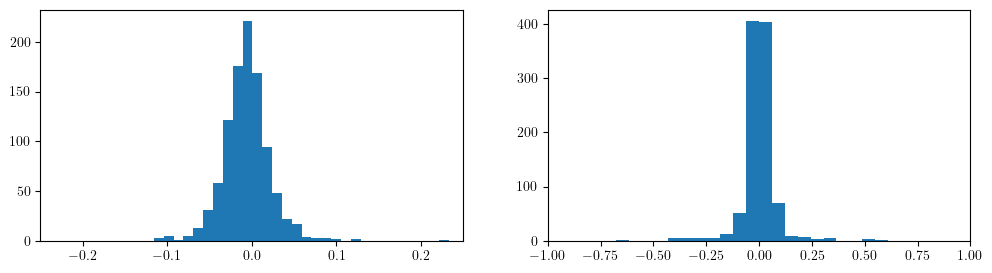

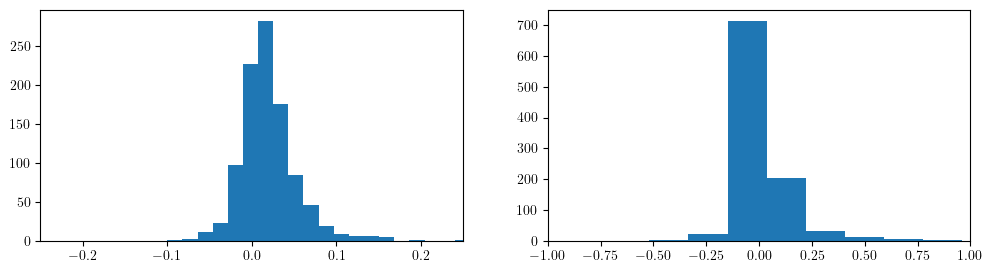

In [38]:
fig,ax=plt.subplots(1,2,figsize=(12,3))
ax[0].hist(anisotropic_model_rel_errs_posneg_tot, bins=30)
ax[0].set_xlim([-0.25,0.25])
ax[1].hist(anisotropic_model_rel_errs_posneg_core, bins=40)
ax[1].set_xlim([-1,1])


fig,ax=plt.subplots(1,2,figsize=(12,3))
ax[0].hist(isotropic_model_rel_errs_posneg_tot, bins=20)
ax[0].set_xlim([-0.25,0.25])
ax[1].hist(isotropic_model_rel_errs_posneg_core, bins=20)
ax[1].set_xlim([-1,1])